# Stage 2: Exploratory Data Analysis (EDA)

**Goal of this step:** We want to determine whether loyal and non-loyal clients behave differently enough to justify training separate demand prediction models. We compare the two groups across demand levels, distance sensitivity, geographic spread, and firm characteristics.

>Note: This notebook is for visualization purpose. Most functions are defined in the `handlers/eda_handlers.py` file.

In [9]:
import sys
sys.path.append('handlers')
import matplotlib.pyplot as plt
import handlers.eda_handlers as eda

df = eda.load_historic()
print(f"{len(df)} historic clients — {df['loyal'].sum()} loyal ({df['loyal'].mean():.0%}), {(df['loyal'] == 0).sum()} non-loyal")

500 historic clients — 105 loyal (21%), 395 non-loyal


## 1. Demand Distribution

First comparison: do loyal clients generate higher or more stable demand than non-loyal ones?

In [2]:
eda.demand_summary(df)

,n,mean,median,std,min,max
loyal,,,,,,
Non-Loyal,395,49.08,49.91,34.08,0.00,125.90
Loyal,105,84.25,83.66,30.52,16.88,142.63


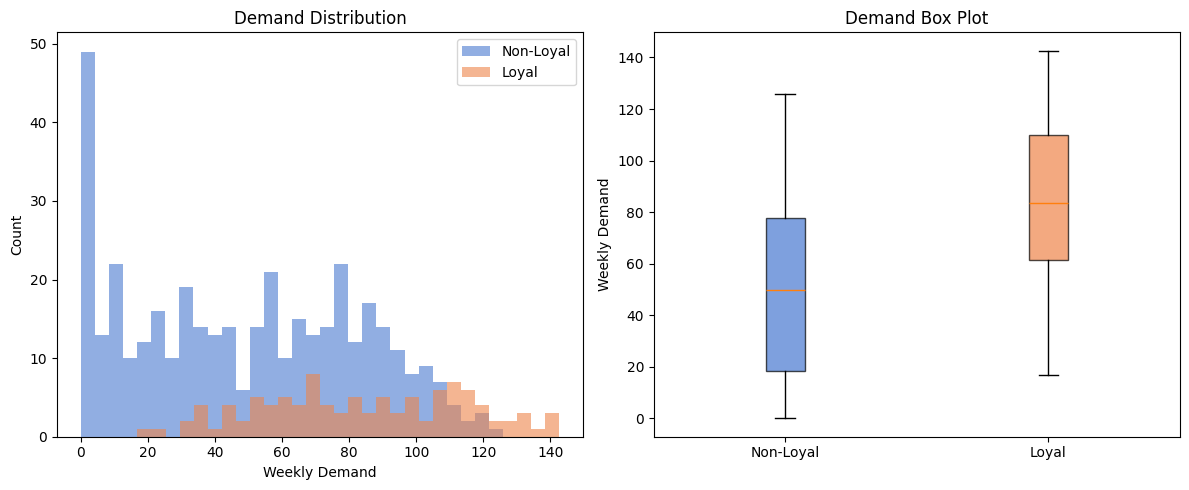

In [3]:
eda.plot_demand_distribution(df)
plt.show()

## 2. Distance Sensitivity

A key assumption is that demand decreases with distance. We check whether the two groups respond to distance differently — a different slope means a different model is needed for each.

In [4]:
eda.distance_sensitivity_table(df)

,Pearson r,Slope (demand / dist unit)
Group,,
Non-Loyal,-0.279,-0.805
Loyal,0.013,0.055


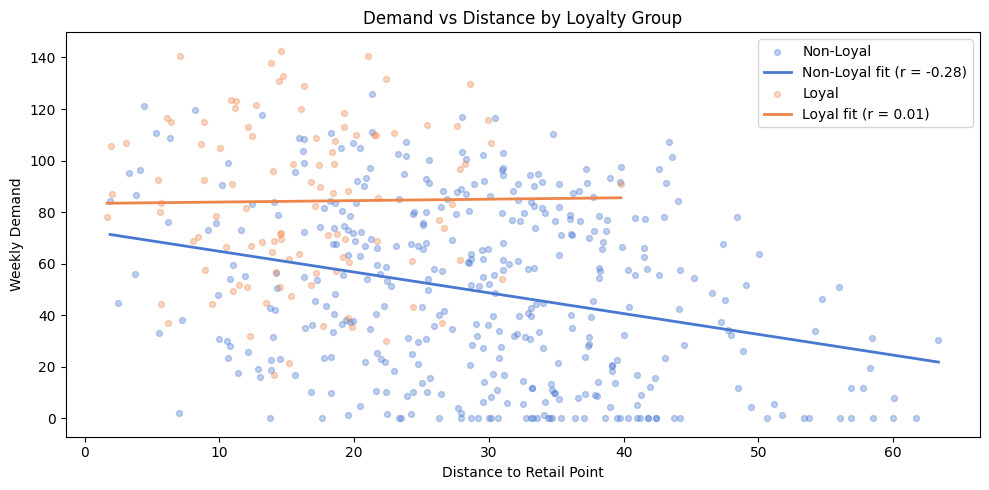

In [5]:
eda.plot_demand_vs_distance(df)
plt.show()

## 3. Geographic Distribution

We check whether loyalty is uniformly spread across the city or concentrated in specific areas, which would affect store placement decisions.

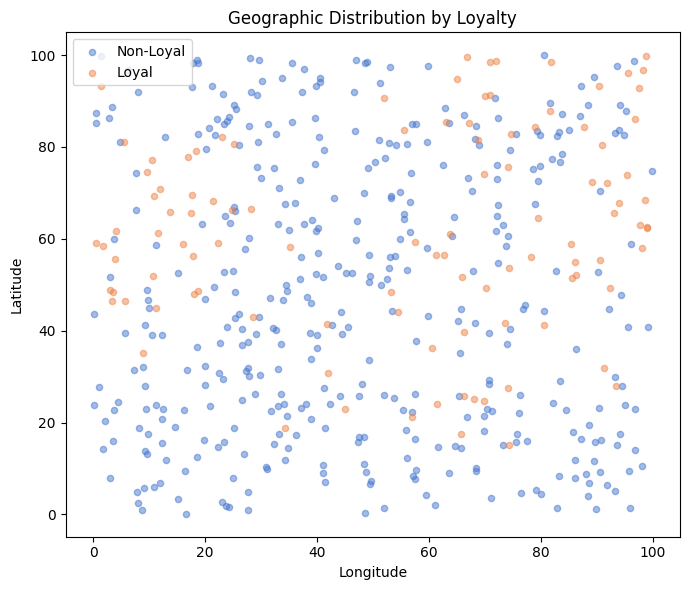

In [6]:
eda.plot_geographic_distribution(df)
plt.show()

## 4. Client Profile Comparison

We compare firm characteristics (size, age, volume, staff) between groups to see whether loyal clients have a distinct profile.

In [7]:
eda.feature_means(df)

,employes,surface,firm_age,monthly_volume,purchase_staff,dist_retail_point
loyal,,,,,,
Non-Loyal,230.48,1018.85,24.96,79.46,4.92,29.51
Loyal,333.15,1121.68,26.97,91.02,4.98,16.12


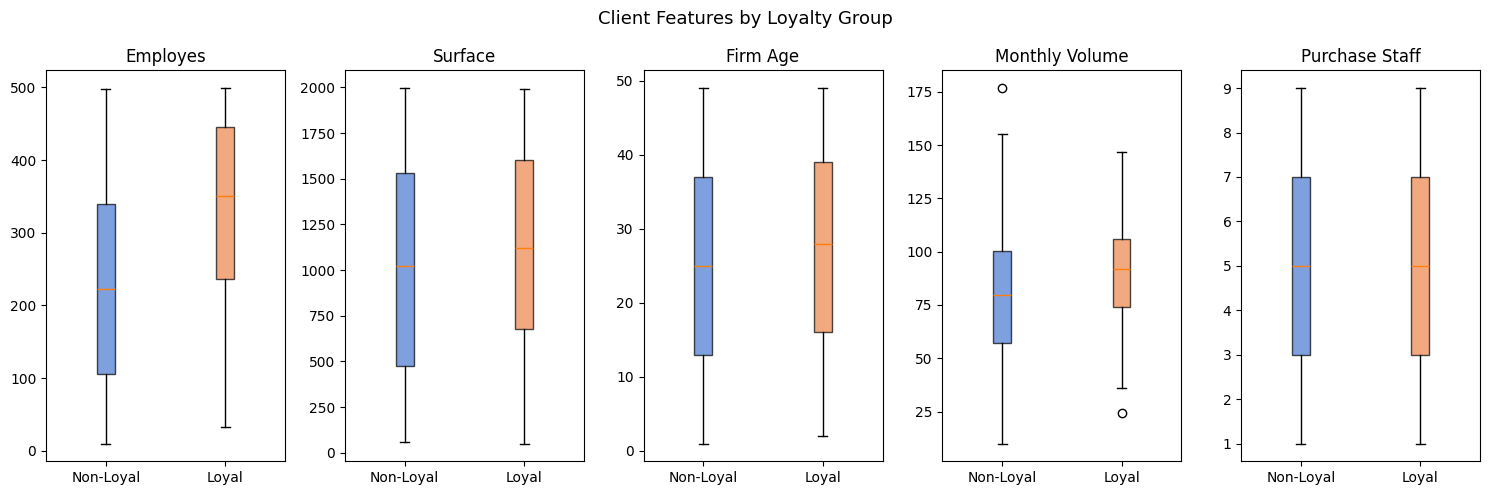

In [8]:
eda.plot_feature_comparison(df)
plt.show()

## Main takeaways after EDA

Based on this EDA, we see that:

### 1. Loyal clients generate a lot more demand
We see that loyal clients buy around 70% more per week on avaerage (84 against 49 units). No loyal client has 0 demand, while 40 non-loyal clients (around 10% of non-loyal clients) buy nothing.
=> **loyal clients demand is higher and easier to predict**.

### 2. Distance affects the two groups in different ways:
**For non-loyal clients:**

Every additional distance unit costs around 0.8 units of weekly demand (cf. distance table). => **Those clients buy less the farther teh store is**.

**For loyal clients:**

The slope is essentially 0 (cf. demand vs distance loyalty group fit). This means **demands stays the same regardless of the distance to the store**.

### 3. Clients profile
The loyal clients have in general more employees, more monthly transaction volume and larger premise than non loyal clients. **This means they are larger companies who can pay more**.
They are also generaly (around 45%) closer to the stores (16km average vs 30km average) which means that **companies that were already close to the stores were more likely to be loyal**.
